In [12]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [13]:
# 문제 6: 성별과 연령대를 조합하여 (예: '20대 남성'), 각 그룹의 평균 주문액(AOV)을 비교하세요.
# 시각화: 히트맵

# 비즈니스 목적: 보다 세분화된 고객 그룹(세그먼트)의 특징을 분석하고, 특정 그룹에 대한 타겟 마케팅 전략의 효과를 극대화합니다.

# 출력 결과를 보고 코딩하세요

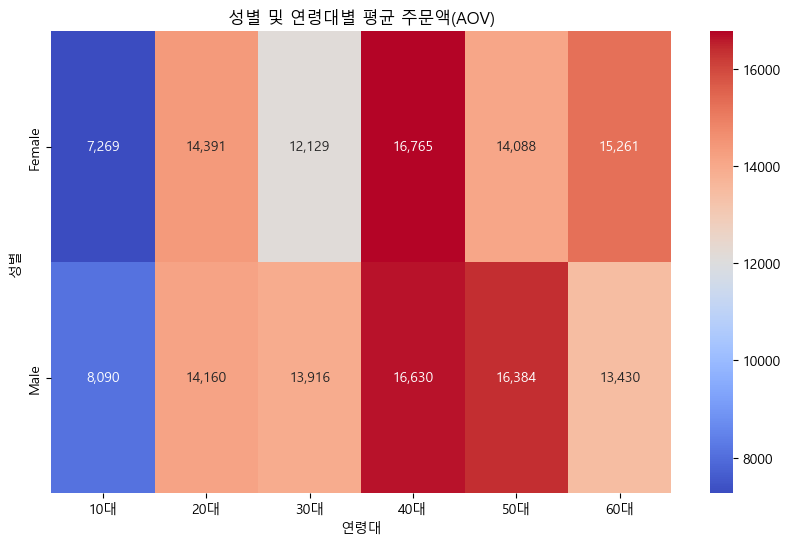



In [14]:
# 나와야 하는 데이터 : 연령대 그룹, 성별, 성별 및 연령대별 평균 주문액(AOV)

# 현재 있는 데이터 : gender(성별), age(고객 나이) , total_sales(총 주문액), order_id(주문 ID)
# quantity(주문 수량)

# 추가로 만들어야 하는 데이터 : age_group(연령대 그룹), AOV(평균 주문액)

# 70대 이상 데이터 불균형 때문에 제외


In [15]:
# 1) age 컬럼을 숫자형으로 안전 변환
# df['age']는 Series; to_numeric은 변환된 Series 반환. 변환 실패 시 NaN으로 표시.
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# 2) 연령대 변환 함수 정의 (70대 이상은 제외 -> None 반환)
def to_age_group_no_70(age):
    # 입력 age: 숫자 또는 NaN; 반환: 문자열(예: '20대') 또는 None
    if pd.isna(age):
        return None
    try:
        age = int(age)
    except Exception:
        return None
    if 10 <= age < 20:
        return '10대'
    if 20 <= age < 30:
        return '20대'
    if 30 <= age < 40:
        return '30대'
    if 40 <= age < 50:
        return '40대'
    if 50 <= age < 60:
        return '50대'
    if 60 <= age < 70:
        return '60대'
    # 70 이상은 None -> 이후 분석에서 제외됨
    return None

# 3) age_group 컬럼 생성 (Series를 DataFrame에 추가)
df['age_group'] = df['age'].apply(to_age_group_no_70)

# 4) 연령대가 지정된 행만 필터링하여 별도 DataFrame 생성
# df_age_filtered는 DataFrame; 원본 df는 변경되지 않음(copy 사용으로 안전)
df_age_filtered = df[df['age_group'].notna()].copy()

# 5) gender 값 정리 (Series 연산)
# 문자열을 통일 ('Male','Female' 형태). 그 외는 'Unknown'으로 표준화.
df_age_filtered['gender'] = df_age_filtered['gender'].astype(str).str.strip().str.title()
df_age_filtered.loc[~df_age_filtered['gender'].isin(['Male', 'Female']), 'gender'] = 'Unknown'

# 6) total_sales 보정: 컬럼이 없으면 quantity * price로 생성
if 'total_sales' not in df_age_filtered.columns:
    # quantity, price는 Series. to_numeric으로 안전 변환 후 NaN->0 처리
    df_age_filtered['quantity'] = pd.to_numeric(df_age_filtered['quantity'], errors='coerce').fillna(0)
    df_age_filtered['price'] = pd.to_numeric(df_age_filtered['price'], errors='coerce').fillna(0)
    # total_sales는 Series(숫자) 생성
    df_age_filtered['total_sales'] = df_age_filtered['quantity'] * df_age_filtered['price']

# 7) 성별(gender) 및 연령대(age_group)별 평균 주문액(AOV) 계산 (pivot_table 결과는 DataFrame)
aov_pivot = df_age_filtered.pivot_table(
    index='gender',                # 결과 DataFrame의 인덱스(행)로 gender 사용
    columns='age_group',           # 결과 DataFrame의 컬럼(열)으로 age_group 사용
    values='total_sales',          # 집계 대상 Series
    aggfunc='mean',                # 평균 계산 (AOV)
    dropna=True                    # 완전히 NaN인 그룹은 제거
)

# 8) 연령대 컬럼 순서 재정렬 (10대~60대). 존재하는 컬럼만 선택.
desired_order = ['10대', '20대', '30대', '40대', '50대', '60대']
cols_in_order = [c for c in desired_order if c in aov_pivot.columns]
aov_pivot = aov_pivot.reindex(columns=cols_in_order)

# 9) 성별 행 순서 재정렬: Male, Female, (Unknown 있으면 뒤에 추가)
desired_gender_order = ['Male', 'Female']
genders_present = [g for g in desired_gender_order if g in aov_pivot.index]
if 'Unknown' in aov_pivot.index:
    genders_present.append('Unknown')
aov_pivot = aov_pivot.reindex(index=genders_present)

# 계산 파트 결과: aov_pivot (pandas DataFrame)
# aov_pivot.index -> 성별 리스트 (예: ['Male','Female',...])
# aov_pivot.columns -> 연령대 리스트 (예: ['10대','20대',...'])
# aov_pivot.loc['Male','30대'] 같은 방식으로 평균 주문액(숫자)에 접근 가능

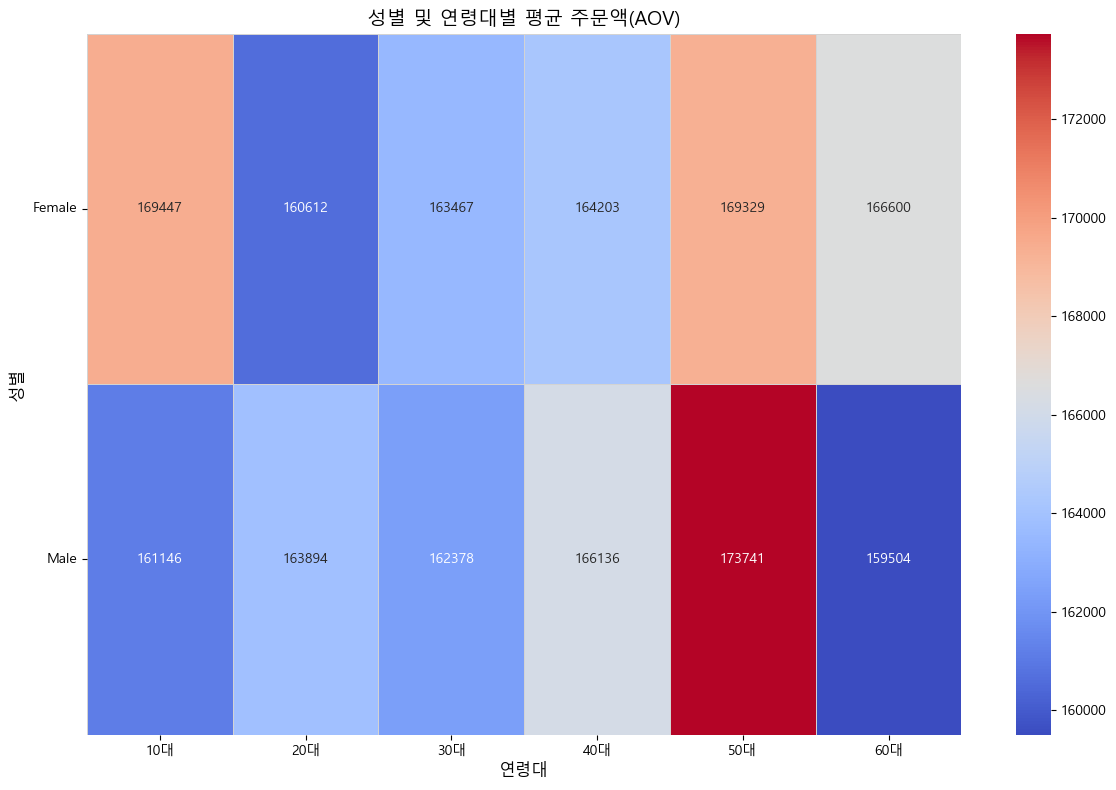

In [23]:
# 시각화 파트 시작
import matplotlib.pyplot as plt    # 모듈: matplotlib.pyplot (Figure, Axes)
import seaborn as sns              # 모듈: seaborn (통계 시각화)

# 1) 한글 폰트 및 마이너스 기호 안전 설정 (plt/Seaborn 동시 적용)
# plt.rc('font', family='Malgun Gothic')               # matplotlib에 폰트 설정
# plt.rcParams['axes.unicode_minus'] = False           # 마이너스 깨짐 방지
# sns.set(font='Malgun Gothic', rc={'axes.unicode_minus': False})

# 2) 컬러맵 준비: 파랑 -> 빨강 그라데이션 (coolwarm)
cmap = sns.color_palette("coolwarm", as_cmap=True)  # matplotlib 호환 컬러맵

# 3) Figure 생성 (matplotlib Figure 객체)
plt.figure(figsize=(12, 8))  # 가로12인치 x 세로8인치

# 4) 히트맵 그리기 (입력: aov_pivot DataFrame)
# 반환값 ax는 matplotlib Axes 객체

aov_pivot = aov_pivot.loc[['Female', 'Male']] # 피벗 테이블의 행 순서 정렬

ax = sns.heatmap(
    aov_pivot,            # 입력 DataFrame: 행=gender, 열=age_group, 값=AOV
    annot=True,           # 각 셀에 수치 표기 (텍스트)
    fmt='.0f',            # 정수 형태로 표시 (예: 12345)
    cmap=cmap,            # 지정한 컬러맵 적용 (파랑->빨강)
    cbar=True,            # 오른쪽 컬러바(범례) 표시
    linewidths=0.5,       # 셀 경계선 굵기
    linecolor='lightgray' # 셀 경계선 색상
)

# 5) 제목 및 축 라벨 설정 (Axes 메서드)
ax.set_title('성별 및 연령대별 평균 주문액(AOV)', fontsize=14)  # 타이틀
ax.set_xlabel('연령대', fontsize=12)                           # X축 라벨
ax.set_ylabel('성별', fontsize=12)                             # Y축 라벨

# 6) 틱(레이블) 회전 및 정렬
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # X축 레이블 수평 배치(0도)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Y축 레이블 수평 배치(0도)

# 7) 컬러바 레이블 추가 (matplotlib Colorbar 객체 접근)
cbar = ax.collections[0].colorbar


# 8) 레이아웃 조정 및 출력
plt.tight_layout()  # 여백 자동 조정
plt.show()          # 그래프 렌더링

In [ ]:
# 1. 분석에 필요한 컬럼만 선택
quest_cols = ['order_id', 'gender', 'age', 'total_sales', 'quantity']
# 리스트 quest_cols: 분석에 필요한 컬럼명을 문자열로 나열
# order_id: 주문 식별자 (문자열 또는 숫자형)
# gender: 고객 성별 (문자열)
# age: 고객 나이 (숫자형)
# total_sales: 주문당 총 매출액 (숫자형)
# quantity: 주문 수량 (상품 개수)

# 2. 70세 이상 고객 제외 + 연령대(age_group) 생성
df_quest24 = (
    df[df['age'] < 70][quest_cols].copy()  
    # df['age'] < 70: 나이가 70세 미만인 행만 필터링 (Boolean indexing)
    # [quest_cols]: 필요한 컬럼만 선택
    # .copy(): 원본 df를 변경하지 않기 위해 복사본 생성

    .assign(age_group=lambda x: ((x['age'] // 10) * 10).astype(str) + '대')  
    # .assign(): 새로운 컬럼 추가
    # lambda x: 익명 함수로 age를 10으로 나눈 몫을 구함 → 10, 20, 30 등
    # .astype(str): 정수형을 문자열로 변환
    # + '대': 문자열 결합 → '20대', '30대' 등으로 표현
    # 결과: age_group 컬럼이 생기고, 값은 '10대' ~ '60대'
)

# 3. 성별 값 정리 ('Male', 'Female' 외는 'Unknown'으로 통일)
df_quest24['gender'] = df_quest24['gender'].astype(str).str.strip().str.title()
# .astype(str): gender 값을 문자열로 변환 (예: NaN → 'nan')
# .str.strip(): 앞뒤 공백 제거
# .str.title(): 첫 글자만 대문자로 변환 → 'male' → 'Male'

df_quest24.loc[~df_quest24['gender'].isin(['Male', 'Female']), 'gender'] = 'Unknown'
# .loc[]: 조건에 맞는 행 선택
# ~isin(): 'Male', 'Female'이 아닌 값 → True
# 해당 행의 gender 값을 'Unknown'으로 변경

# 4. 성별 + 연령대별로 그룹화하여 총 매출액 계산
aov_result = (
    df_quest24.groupby(['age_group', 'gender'])  # 그룹 기준: 연령대 + 성별
    .agg(
        total_revenue=('total_sales', 'sum'),    # 그룹별 총 매출액 계산
        # order_counts=('quantity', 'sum')       # (주석 처리됨) 상품 수량 기준 주문 수
        # order_counts=('order_id', 'count')     # (주석 처리됨) 주문 건수 기준
    )
    .assign(aov=lambda x: x['total_revenue'] / len(df_quest24))  
    # AOV 계산: 전체 주문 수(len(df_quest24))로 나눔 → 그룹별 AOV 비율
    # x는 DataFrame (groupby 결과), x['total_revenue']는 Series
    # 결과: aov 컬럼 추가됨

    .reset_index()  # 그룹 인덱스를 일반 컬럼으로 변환
)

# 5. 결과 확인 
print(aov_result)
# 출력: age_group, gender, total_revenue, aov 컬럼 포함된 DataFrame

   age_group  gender  total_revenue           aov
0        10대  Female       72692800   7383.727781
1        10대    Male       80895200   8216.881666
2        20대  Female      143908000  14617.369223
3        20대    Male      141604100  14383.351955
4        30대  Female      121292200  12320.182834
5        30대    Male      139158300  14134.921280
6        40대  Female      167651300  17029.080752
7        40대    Male      166302300  16892.056882
8        50대  Female      140882000  14310.005079
9        50대    Male      163837500  16641.696293
10       60대  Female      152606000  15500.863382
11       60대    Male      134302600  13641.706450


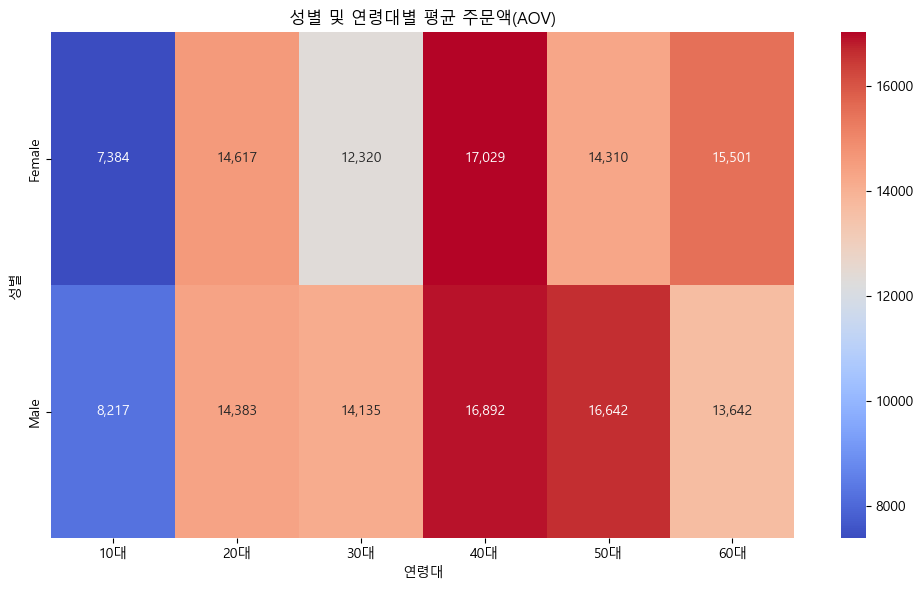

In [25]:
# 6. 피벗 테이블로 변환 (히트맵용 구조로 재배치)
pivot_aov = aov_result.pivot_table(
    index='gender',         # 행 인덱스: 성별
    columns='age_group',    # 열 인덱스: 연령대
    values='aov'            # 셀 값: 평균 주문액 (AOV)
)
# 결과: 성별 x 연령대 매트릭스 형태의 DataFrame 생성

# 7. 히트맵 그리기
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))  # 그래프 크기 설정 (가로 10인치, 세로 6인치)

# 8. 셀 안에 표시할 숫자 포맷 지정
annot_data = pivot_aov.map(lambda x: f'{x:,.0f}')
# .map(): 각 셀의 값을 포맷팅
# f'{x:,.0f}': 천 단위 콤마 + 소수점 없이 정수로 표시
# 예: 12345.67 → '12,346'

# 9. 히트맵 생성
sns.heatmap(
    pivot_aov,              # 데이터: 성별 x 연령대 AOV
    annot=annot_data,       # 셀 안에 표시할 값 (문자열)
    fmt='',                 # 숫자 포맷은 이미 문자열로 처리했으므로 빈 문자열
    cmap='coolwarm'         # 색상 팔레트: 파랑~빨강 (낮음~높음)
)

# 10. 히트맵 제목 및 축 라벨 설정
plt.title('성별 및 연령대별 평균 주문액(AOV)')  # 그래프 제목
plt.xlabel('연령대')                          # X축 라벨
plt.ylabel('성별')                            # Y축 라벨
plt.tight_layout()                            # 여백 자동 조정
plt.show()                                    # 그래프 출력

In [ ]:
# 1) 분석에 쓸 컬럼 이름을 리스트로 선언
#    자료형: list (문자열 요소들의 순서화된 컨테이너)
#    목적: 이후 df[quest_cols]로 필요한 컬럼만 깔끔하게 추출하기 위함.
#    이유: 원본 df에 불필요한 컬럼이 많을 때 처리 비용과 실수(타입 혼합 등)를 줄여줌.
quest_cols = ['order_id', 'gender', 'age', 'total_sales', 'quantity']
# 리스트 quest_cols: 분석에 필요한 컬럼명을 문자열로 나열
# order_id: 주문 식별자 (문자열 또는 숫자형)
# gender: 고객 성별 (문자열)
# age: 고객 나이 (숫자형)
# total_sales: 주문당 총 매출액 (숫자형)
# quantity: 주문 수량 (상품 개수)


# 2) 70세 이상을 제외하고, 필요한 컬럼만 골라 복사본 생성 및 연령대(age_group) 컬럼 추가
#    df[df['age'] < 70]          -> Boolean indexing: age 컬럼이 70 미만인 행만 선택 (Series of bool)
#    [quest_cols]                -> DataFrame 컬럼 슬라이싱: 필요한 컬럼들만 남김 (returns DataFrame)
#    .copy()                     -> 복사본 생성: 원본 df 변경을 방지 (DataFrame)
#    .assign(age_group=...)      -> 새 컬럼 생성: 기존 DataFrame에 안전하게 컬럼 하나 추가
df_quest24 = (
    df[df['age'] < 70][quest_cols].copy()
    .assign(
        age_group = lambda x: (
            # x['age'] // 10           -> 정수 나눗셈(floor division): age를 10으로 나눈 몫 (Series of float/int)
            # ( ... ) * 10             -> 10단위로 환원: 22 -> 20, 35 -> 30 (연령대 기준)
            # .astype(str)             -> 문자열 변환: 숫자 -> '20'
            # + '대'                   -> 문자열 결합: '20' + '대' -> '20대'
            # 이유: 간단한 수식으로 10대~60대 라벨 자동 생성 (코드 가독성 및 속도 장점)
            ((x['age'] // 10) * 10).astype(str) + '대'
        )
    )
)

# 3) (디버깅용 출력 — 선택적) 일부 행 확인
# print(df_quest24.head(50))
# print(f"행 수: {len(df_quest24)}")
# 위 출력은 데이터 필터가 의도대로 작동했는지(70세 이상 제거, 컬럼 선택, age_group 생성) 확인

# 4) 성별 및 연령대별 집계 수행: 총 매출을 그룹별 합으로 계산
#    groupby(['age_group','gender']) -> 그룹화 객체 생성 (연령대 우선, 성별 차례)
#    .agg(total_revenue = ('total_sales','sum')) -> 그룹별로 total_sales 합계 계산 (Series)

aov_result = (
    df_quest24.groupby(['age_group', 'gender'])
    .agg(
        total_revenue = ('total_sales', 'sum'),  # groupby 결과에서 total_sales 컬럼의 합을 total_revenue 라는 새 컬럼으로 만듦
        # order_counts = ('quantity', 'sum')     # (대체 옵션) quantity 합계를 주문 수량으로 사용하려면 활성화
        # order_counts = ('order_id', 'count')   # (대체 옵션) order_id 개수를 주문 건수로 간주하려면 활성화
    )
    # 5) AOV 계산: 현재 코드의 방식은 그룹별 총매출을 전체 주문 수로 나누는 방식
    #    .assign(aov=lambda x: x['total_revenue'] / len(df_quest24))
    #    x: 위에서 생성된 DataFrame (index: age_group,gender; columns: total_revenue [,order_counts])
    #    len(df_quest24): 전체(필터 적용 후) 행 수; 여기서는 전체 주문 건수로 간주됨
    #    결과: 그룹별 총매출 / 전체주문건수 -> 각 그룹이 전체 평균에 기여하는 '건당 평균'처럼 해석 가능
    .assign(aov=lambda x: x['total_revenue'] / len(df_quest24))
    # 6) reset_index(): groupby 결과의 인덱스(연령대, 성별)를 일반 컬럼으로 변환하여 표 형태로 만듦
    .reset_index()
)

# 7) 계산 결과 출력: aov_result는 DataFrame (columns: age_group, gender, total_revenue, aov)
print(aov_result)
# 출력 목적: 그룹별 총매출과 aov 계산값을 표로 확인 (디버깅 및 결과 검증)

   age_group  gender  total_revenue           aov
0        10대  Female       72692800   7383.727781
1        10대    Male       80895200   8216.881666
2        20대  Female      143908000  14617.369223
3        20대    Male      141604100  14383.351955
4        30대  Female      121292200  12320.182834
5        30대    Male      139158300  14134.921280
6        40대  Female      167651300  17029.080752
7        40대    Male      166302300  16892.056882
8        50대  Female      140882000  14310.005079
9        50대    Male      163837500  16641.696293
10       60대  Female      152606000  15500.863382
11       60대    Male      134302600  13641.706450


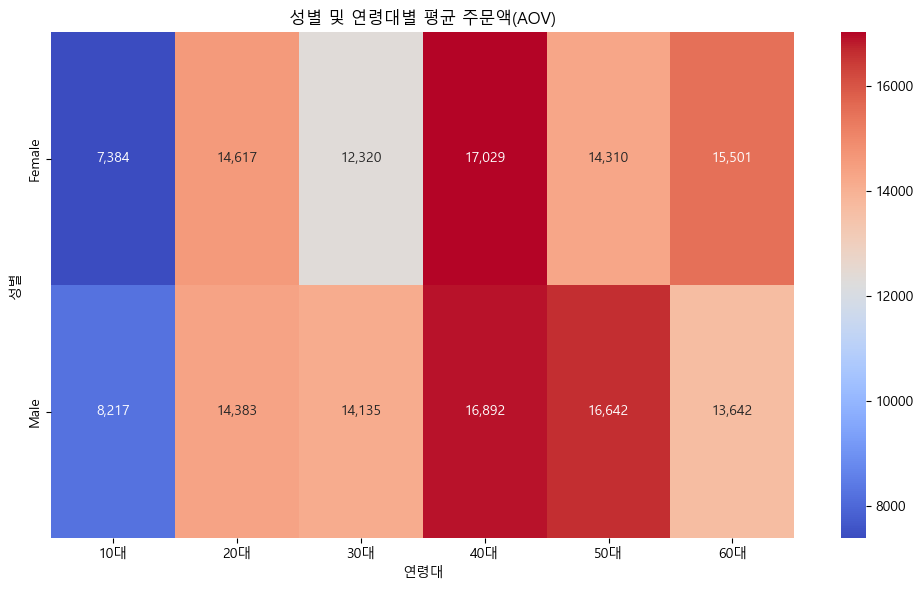

In [27]:
# 8) 피벗 테이블로 변환: 시각화(히트맵)를 위해 "행=성별, 열=연령대" 형태로 재배치
#    aov_result.pivot_table(index='gender', columns='age_group', values='aov')
#    -> DataFrame 반환: index는 gender, columns는 age_group, 각 셀은 해당 그룹의 aov 값
pivot_aov = aov_result.pivot_table(
    index='gender',
    columns='age_group',
    values='aov'
)

# 9) 시각화 라이브러리 임포트 (필요시 이미 임포트했으면 중복 임포트 무해)
import matplotlib.pyplot as plt  # matplotlib.pyplot: 플롯 생성/조작 함수 모음
import seaborn as sns            # seaborn: 통계적 시각화 라이브러리(heatmap 등에 편리)

# 10) figure 크기 설정: 시각화 캔버스의 가로/세로 크기(인치 단위)
plt.figure(figsize=(10, 6))
# 이유: 기본 크기는 작을 수 있어 레이블이 겹치므로 명시적으로 크기를 지정

# 11) 히트맵 내부에 표시할 텍스트(문자열)로 포맷팅
#     pivot_aov.map(lambda x: f'{x:,.0f}') 사용 이유:
#     - pivot_aov의 각 셀(숫자)을 문자열로 포맷해서 천단위 콤마 삽입, 소수점 제거
#     - seaborn.heatmap의 annot 인자로 문자열 Series/DataFrame을 주면 원하는 포맷 그대로 표시 가능
annot_data = pivot_aov.map(lambda x: f'{x:,.0f}')

# 12) 히트맵 생성
#     sns.heatmap(data, annot=annot_data, fmt='', cmap='coolwarm')
#     - data: 2차원 행렬(여기서는 pivot_aov)
#     - annot: 각 셀에 표시할 값 (문자열이나 숫자)
#     - fmt: annot이 숫자일 경우 포맷 지정; 이미 문자열이므로 빈 문자열 사용
#     - cmap: 색상 팔레트 (낮은 값은 파랑, 높은 값은 빨강 계열)
sns.heatmap(pivot_aov, annot=annot_data, fmt='', cmap='coolwarm')

# 13) 제목 및 축 레이블 설정
plt.title('성별 및 연령대별 평균 주문액(AOV)')  # 그래프 제목
plt.xlabel('연령대')                            # x축 레이블 (열: age_group)
plt.ylabel('성별')                              # y축 레이블 (행: gender)

# 14) 레이아웃 조정: 자동으로 축-레이블-타이틀 여백을 조정하여 잘림 방지
plt.tight_layout()

# 15) 플롯을 화면에 보여줌 (인터랙티브 환경 또는 스크립트에서 최종 출력)
plt.show()

In [17]:
# 🧩 2️⃣ columns: 내용 분석

# 지금 이 리스트는 df 안의 모든 컬럼(속성) 이름이에요.

# 컬럼 이름	역할 설명
# order_id	주문 고유번호
# customer_id	고객 고유번호
# product_id	제품 고유번호
# order_date	주문한 날짜
# quantity	주문 수량
# payment_method	결제 방식 (카드, 계좌이체 등)
# payment_status	결제 상태 (완료, 취소 등)
# payment_date	결제일
# product_name	제품 이름
# category	상품 카테고리
# price	상품 가격 (단가)
# stock	재고 수량
# name	고객 이름
# gender	고객 성별
# age	고객 나이
# join_date	고객 가입일
# city	고객 도시
# shipping_id	배송 고유번호
# shipping_company	배송사 이름
# shipping_status	배송 상태
# shipping_start_date	배송 시작일
# shipping_end_date	배송 완료일
# total_sales	총 주문 금액 (quantity × price) — ✅ 우리가 분석에 쓸 핵심 컬럼
# age_group	연령대 (예: 10대, 20대 …) — ✅ 히트맵 만들 때 꼭 필요